In [108]:
%load_ext autoreload
%autoreload 2

import numpy as np
from time import time
import matplotlib.pyplot as plt
from main_new_prod import ModelClass
from plots import plot_shares, plot_series
from helper_functions import params_to_latex

model = ModelClass()

par = model.par
sim = model.sim

model.solve(do_print=False)

params_to_latex(par)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


The model converges to the steady state:

In [109]:
print(f"Old workers supply in high jobs: {par.l_h_o_ss:.2f}")
print(f"Old workers supply in low jobs: {par.l_l_o_ss:.2f}")
print(f"Wage of old workers in high jobs: {par.wage_h_o_ss:.2f}")
print(f"Wage of old workers in low jobs: {par.wage_l_o_ss:.2f}")

Old workers supply in high jobs: 0.02
Old workers supply in low jobs: 1.49
Wage of old workers in high jobs: 17.47
Wage of old workers in low jobs: 2.39


First, I check that the model aligns with Bianchi and Paradisi, such that the above is true:

\begin{equation*}
    \frac{\partial\bar{w}_{t}^{y}}{\partial l_{h,t-1}^{y}}=\underset{\text{Career spillovers}<0}{\underbrace{\frac{1}{l_{t}^{y}}\left(\mu^{y}-1\right)w_{\ell}^{y}\frac{\partial l_{h}^{y}}{\partial l_{h,t-1}^{y}}}}+\underset{\text{Wage level}>0}{\underbrace{\left[\frac{1}{l_{t}^{y}}\left(\mu^{y}-1\right)l_{h}^{y}+1\right]\frac{\partial w_{\ell}^{y}}{\partial l_{h,t-1}^{y}}}}
\end{equation*}

I find the same signs as they do:

In [110]:
print("Total effect", model.average_wage_change(print_components=True)[0])

Career spillovers -5.660289067241726
Wage level -2.511418531517014
Total effect -8.17170759875874


Then, I check what happens when I increase the retention rate, $\rho_h$, from $0.5$ to $1.0$. It gives a negative shock to the average wage of young:

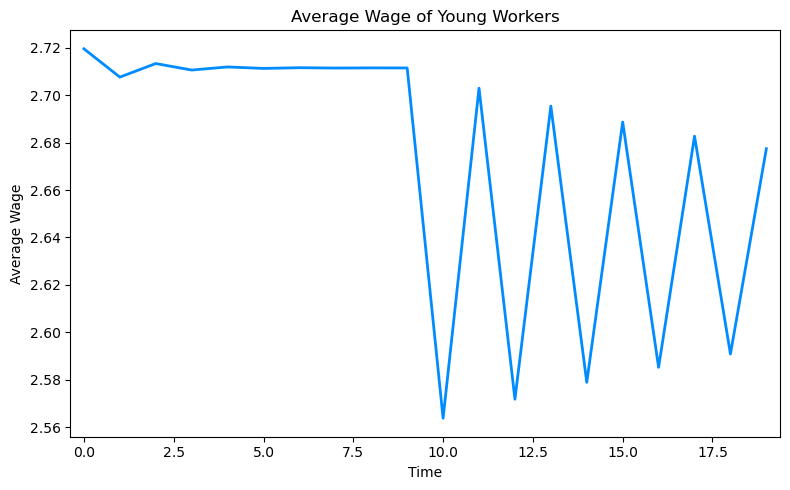

In [111]:
parameter_names = ["rho_h"]
parameter_values = [1.0]

model.simulate_par_shock(parameter_names, parameter_values)

plot_series(model.sim.avg_wage_young, title="Average Wage of Young Workers", ylabel="Average Wage")

Then, I see what happens when I increase the number of older workers in a single period, such that $l_{h,t-1}^{y}\uparrow=l_{h,t}^{o}\uparrow$. I also find a period with negative wage spillovers:

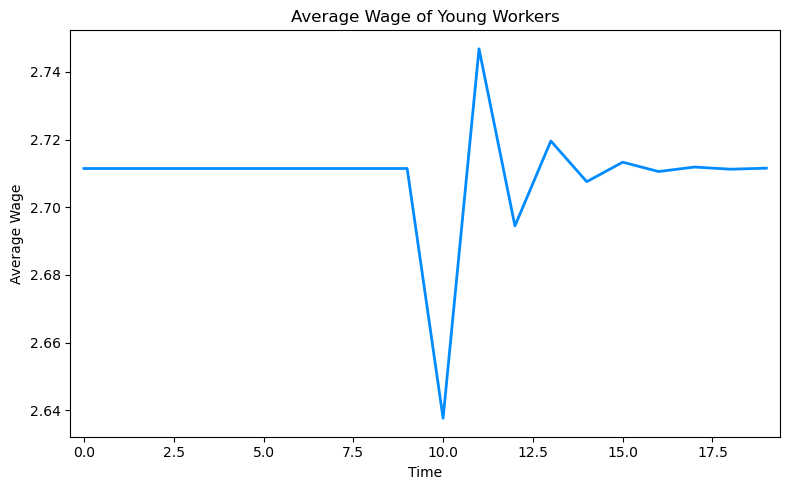

In [98]:
parameter_names = ["l_h_o"]
parameter_values = [sim.l_h_o[0] * 1.5]

model.simulate_series_shock(parameter_names, parameter_values)

plot_series(model.sim.avg_wage_young, title="Average Wage of Young Workers", ylabel="Average Wage")

Finally, I can decompose it into changes in young and old worker shares between high and low job types:

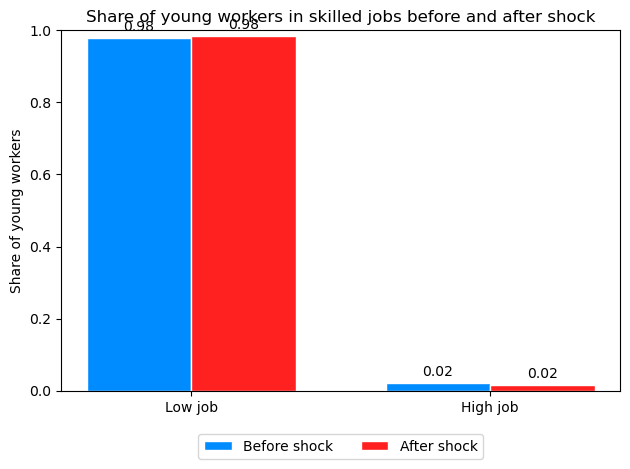

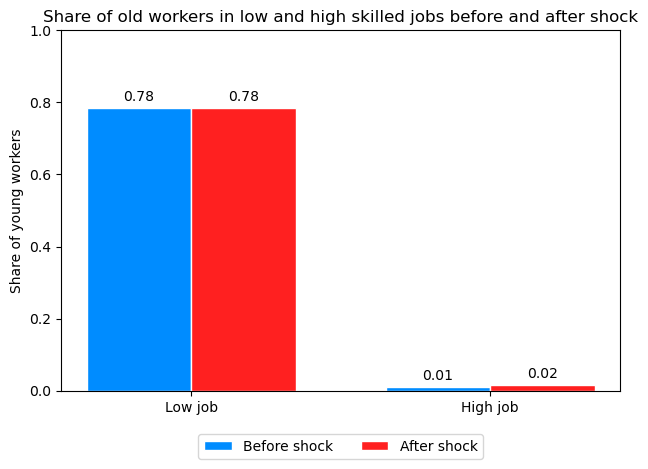

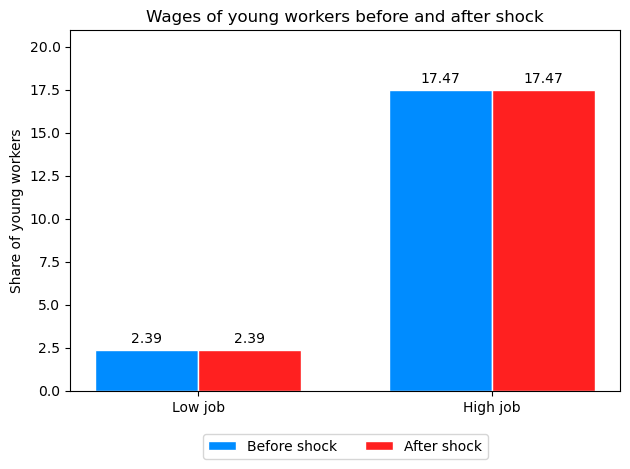

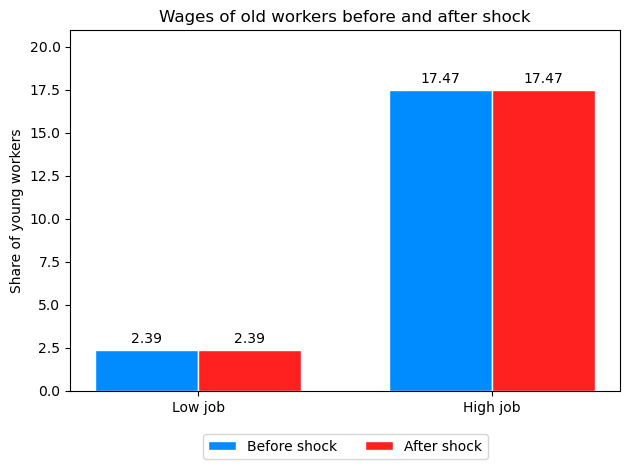

In [99]:
young_low_before = sim.l_l_y[par.T_shock - 1] / par.N_y
young_high_before = sim.l_h_y[par.T_shock - 1] / par.N_y
young_low_after = sim.l_l_y[par.T_shock] / par.N_y
young_high_after = sim.l_h_y[par.T_shock] / par.N_y
plot_shares(young_low_before, young_high_before, young_low_after, young_high_after, "Share of young workers in skilled jobs before and after shock", normalize=True)

old_low_before = sim.l_l_o[par.T_shock - 1] / par.N_y
old_high_before = sim.l_h_o[par.T_shock - 1] / par.N_y
old_low_after = sim.l_l_o[par.T_shock] / par.N_y
old_high_after = sim.l_h_o[par.T_shock] / par.N_y
plot_shares(old_low_before, old_high_before, old_low_after, old_high_after, "Share of old workers in low and high skilled jobs before and after shock", normalize=True)

plot_shares(sim.wage_l_y[par.T_shock - 1], sim.wage_h_y[par.T_shock - 1], sim.wage_l_y[par.T_shock], sim.wage_h_y[par.T_shock], "Wages of young workers before and after shock")
plot_shares(sim.wage_l_o[par.T_shock - 1], sim.wage_h_o[par.T_shock - 1], sim.wage_l_o[par.T_shock], sim.wage_h_o[par.T_shock], "Wages of old workers before and after shock")